### 1)Store processed data in a new CSV file without using built-in DataFrame export functions, manually formatting and writing the data while ensuring optimal storage efficiency.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

df = pd.read_csv("heart_disease.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (25, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
processed_df = df.copy()

processed_df = processed_df.drop_duplicates()

processed_df = processed_df.fillna(processed_df.median(numeric_only=True))

print("Original Shape:", df.shape)
print("Processed Shape:", processed_df.shape)

Original Shape: (25, 14)
Processed Shape: (25, 14)


In [5]:
output_file = "processed_heart_disease.csv"

with open(output_file, "w", encoding="utf-8", newline="") as file:

    headers = processed_df.columns.tolist()
    file.write(",".join(headers) + "\n")

    for row in processed_df.itertuples(index=False, name=None):
        values = []

        for value in row:
            if pd.isna(value):
                values.append("")
            else:
                values.append(str(value))

        file.write(",".join(values) + "\n")

print("File created:", output_file)

File created: processed_heart_disease.csv


In [6]:
new_df = pd.read_csv("processed_heart_disease.csv")

print("New File Shape:", new_df.shape)
new_df.head()

New File Shape: (25, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 2)Create histograms for all numerical features without using built-in plotting functions, implementing binning and frequency calculations manually.

In [7]:
numeric_columns = processed_df.select_dtypes(
    include=np.number
).columns

print("Numerical Features:")
print(numeric_columns.tolist())

Numerical Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


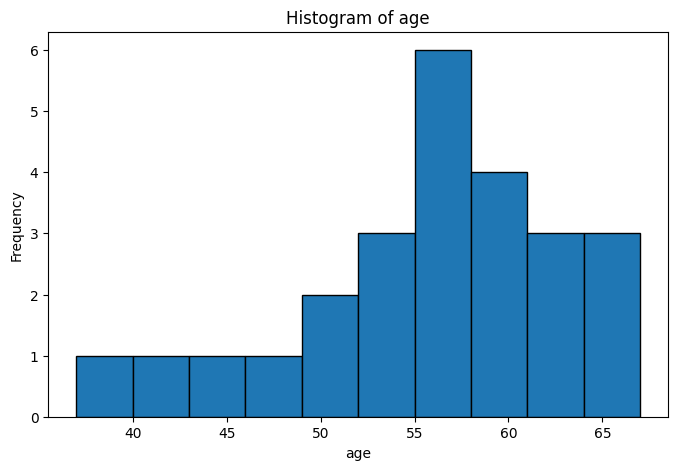

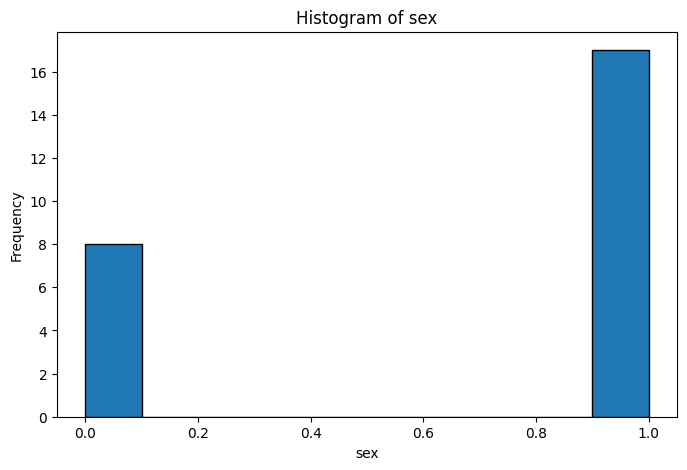

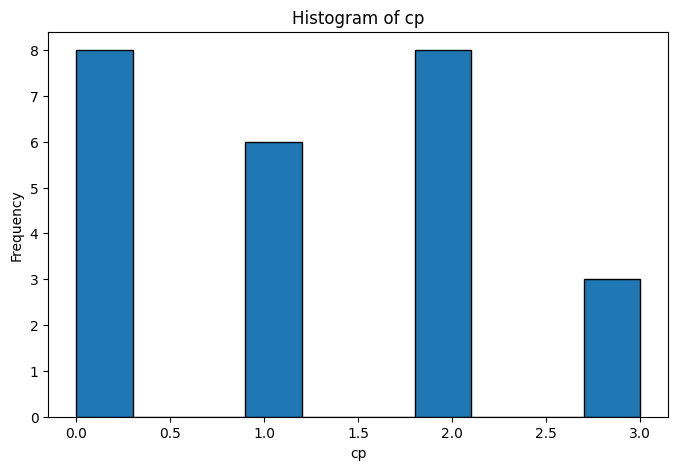

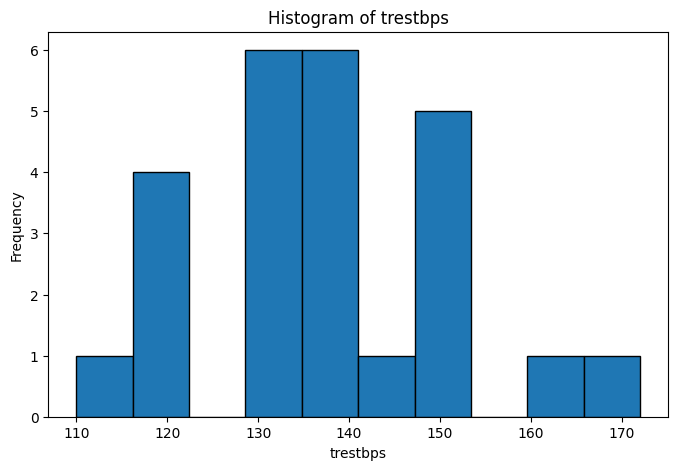

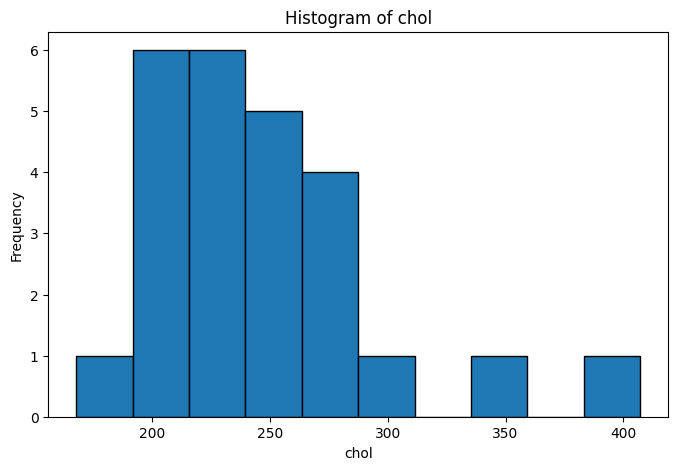

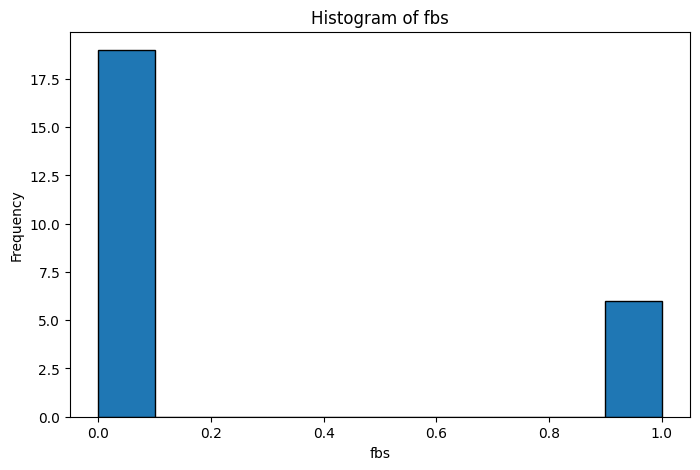

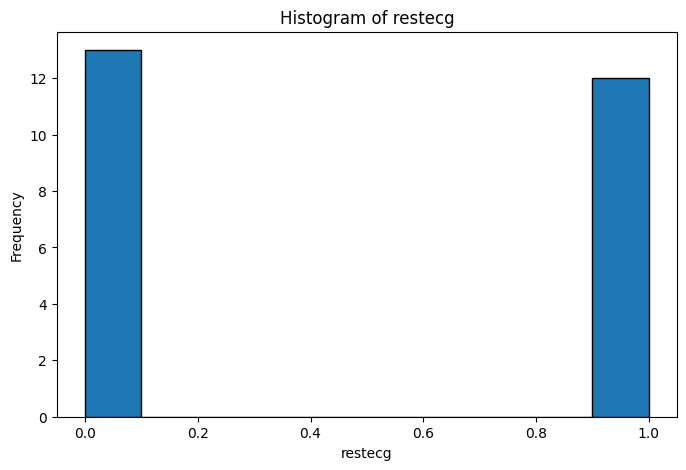

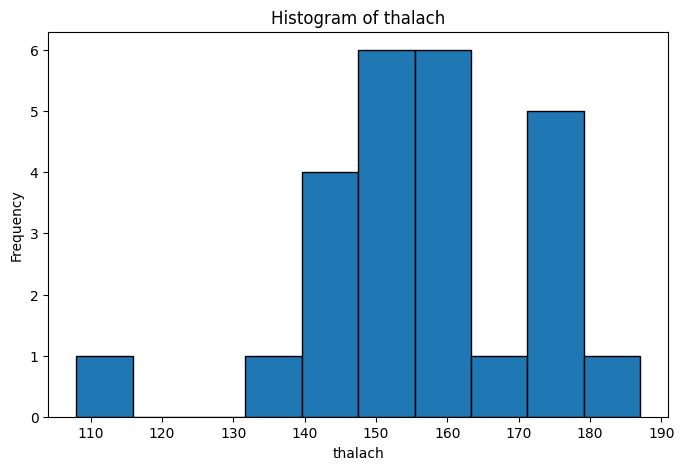

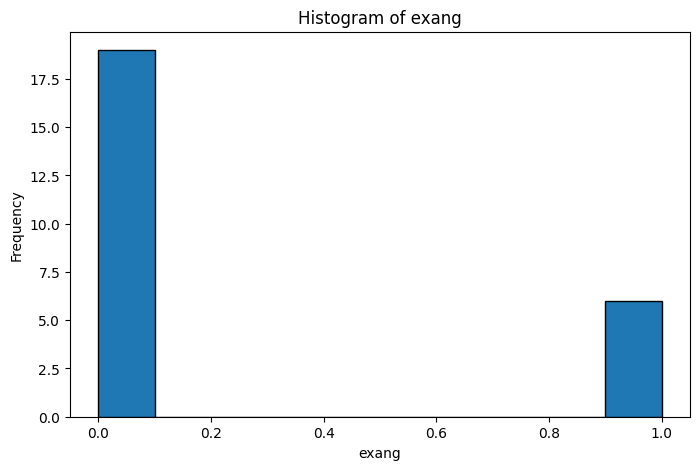

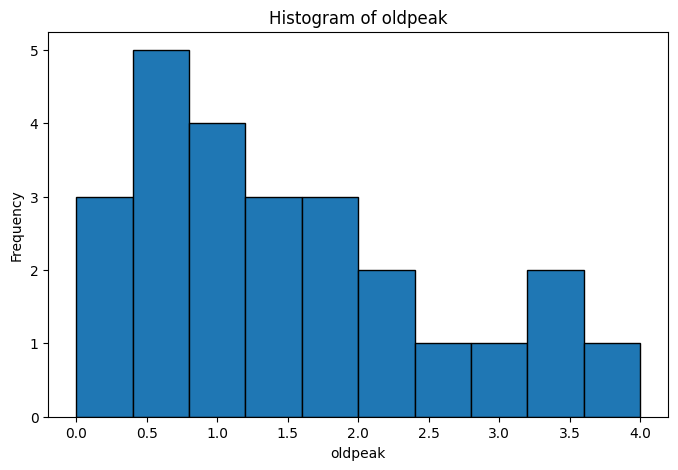

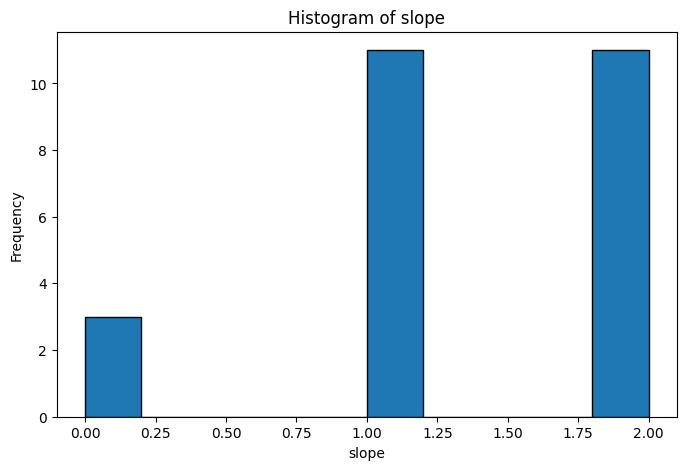

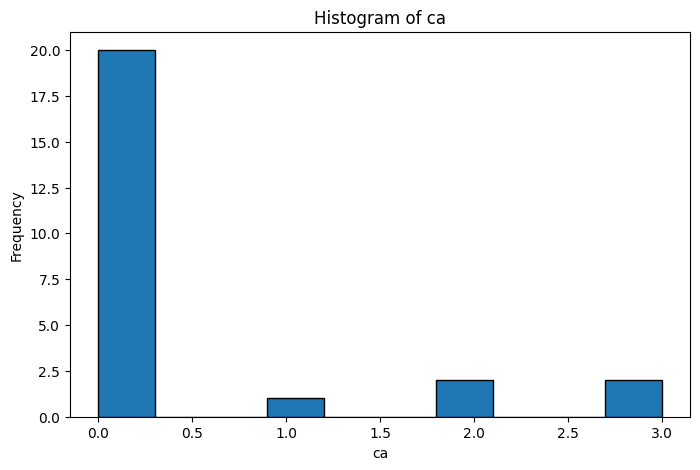

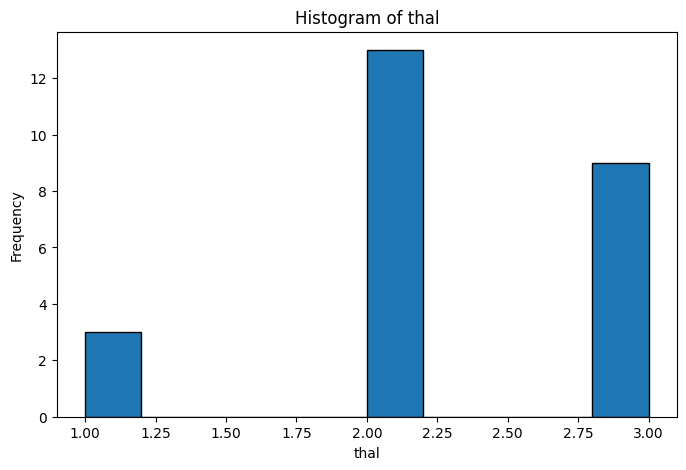

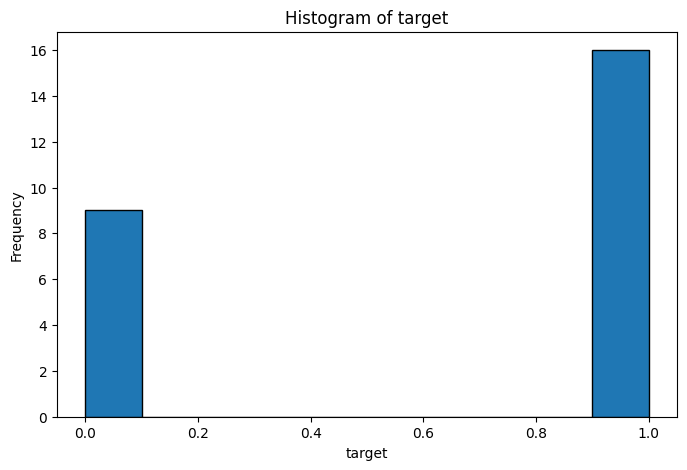

In [8]:
for column in numeric_columns:

    data = processed_df[column].dropna().values

    minimum = data.min()
    maximum = data.max()

    bins = np.linspace(minimum, maximum, 11)
    frequencies = [0] * 10

    for value in data:
        for i in range(10):
            if i == 9:
                if bins[i] <= value <= bins[i + 1]:
                    frequencies[i] += 1
            else:
                if bins[i] <= value < bins[i + 1]:
                    frequencies[i] += 1

    plt.figure(figsize=(8, 5))

    plt.bar(
        bins[:-1],
        frequencies,
        width=np.diff(bins),
        align="edge",
        edgecolor="black"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title("Histogram of " + column)

    plt.show()

### 3)Generate box plots to identify outliers by computing quartiles, IQR, and fences manually, and visualize them using raw Matplotlib drawing functions.

In [9]:
for column in numeric_columns:

    data = processed_df[column].dropna().values

    data = np.sort(data)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    outliers = data[
        (data < lower_fence) |
        (data > upper_fence)
    ]

    print("\nFeature:", column)
    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)
    print("Lower Fence:", lower_fence)
    print("Upper Fence:", upper_fence)
    print("Number of Outliers:", len(outliers))


Feature: age
Q1: 52.0
Q3: 60.0
IQR: 8.0
Lower Fence: 40.0
Upper Fence: 72.0
Number of Outliers: 1

Feature: sex
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Fence: -1.5
Upper Fence: 2.5
Number of Outliers: 0

Feature: cp
Q1: 0.0
Q3: 2.0
IQR: 2.0
Lower Fence: -3.0
Upper Fence: 5.0
Number of Outliers: 0

Feature: trestbps
Q1: 130.0
Q3: 150.0
IQR: 20.0
Lower Fence: 100.0
Upper Fence: 180.0
Number of Outliers: 0

Feature: chol
Q1: 212.0
Q3: 266.0
IQR: 54.0
Lower Fence: 131.0
Upper Fence: 347.0
Number of Outliers: 2

Feature: fbs
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Fence: 0.0
Upper Fence: 0.0
Number of Outliers: 6

Feature: restecg
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Fence: -1.5
Upper Fence: 2.5
Number of Outliers: 0

Feature: thalach
Q1: 148.0
Q3: 171.0
IQR: 23.0
Lower Fence: 113.5
Upper Fence: 205.5
Number of Outliers: 1

Feature: exang
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Fence: 0.0
Upper Fence: 0.0
Number of Outliers: 6

Feature: oldpeak
Q1: 0.6
Q3: 2.0
IQR: 1.4
Lower Fence: -1.4999999999999996
Upper Fence: 4.1
Num

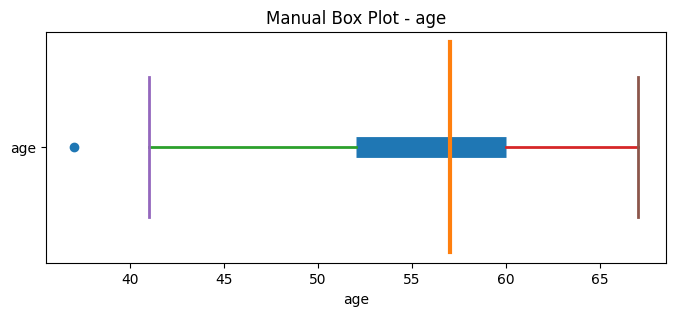

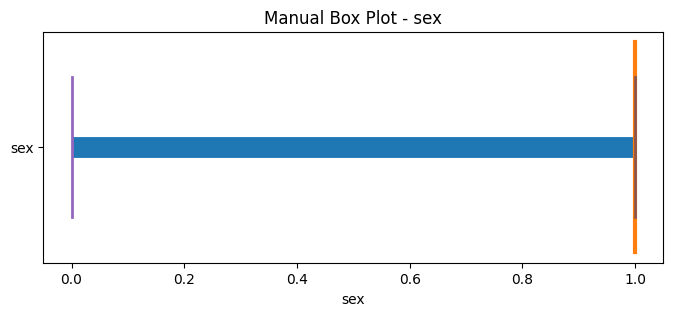

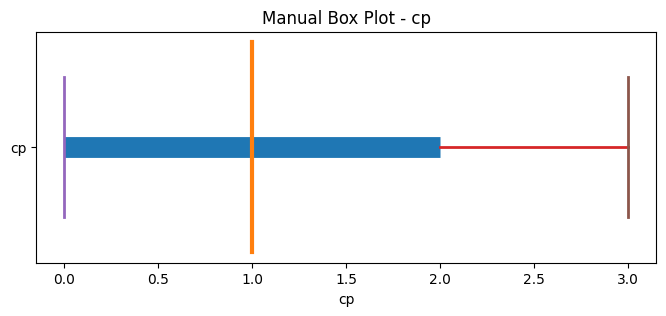

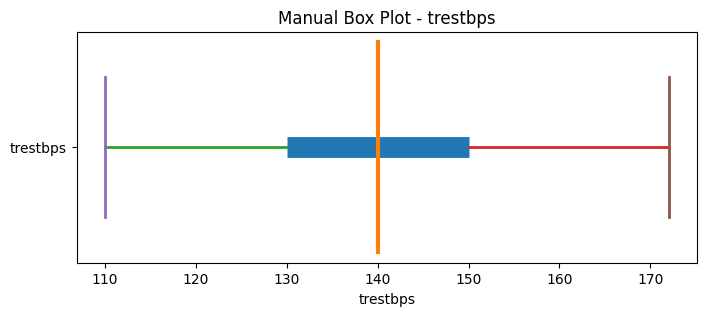

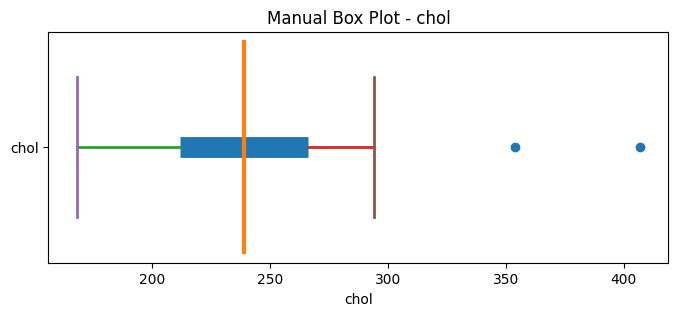

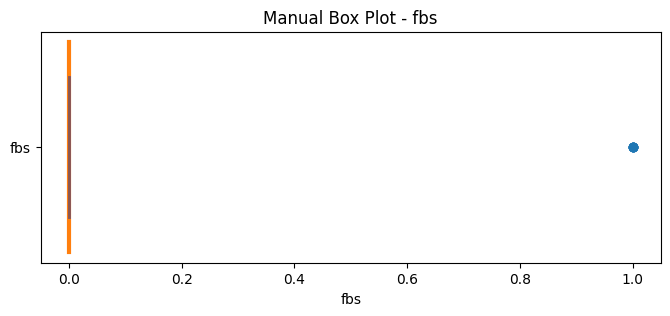

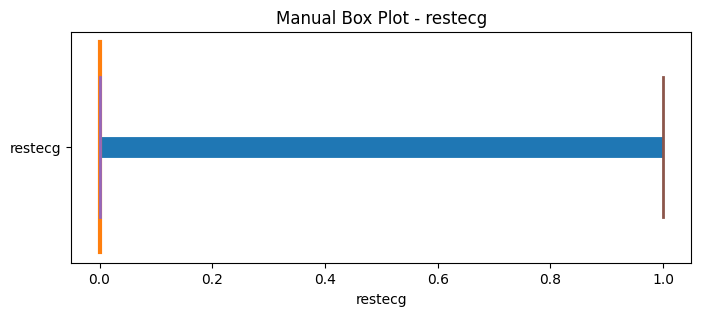

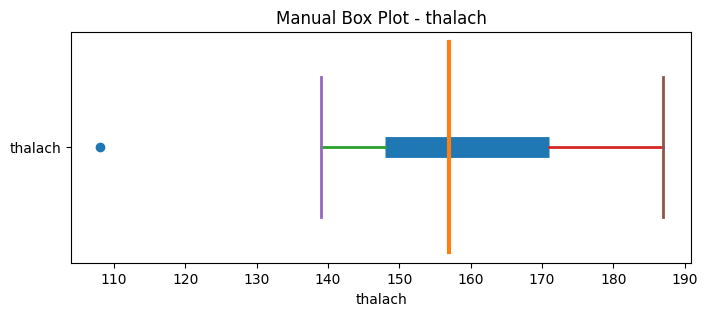

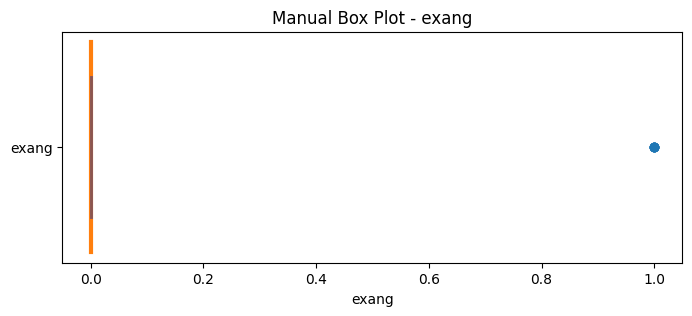

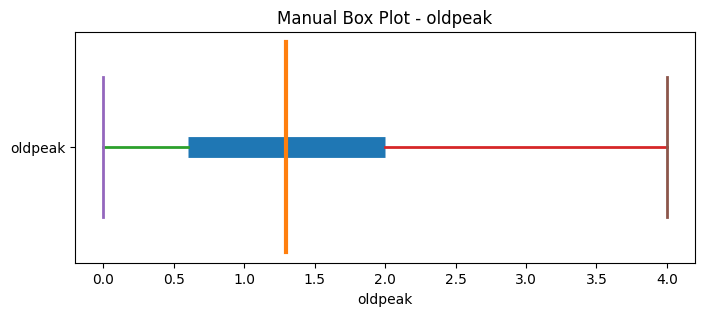

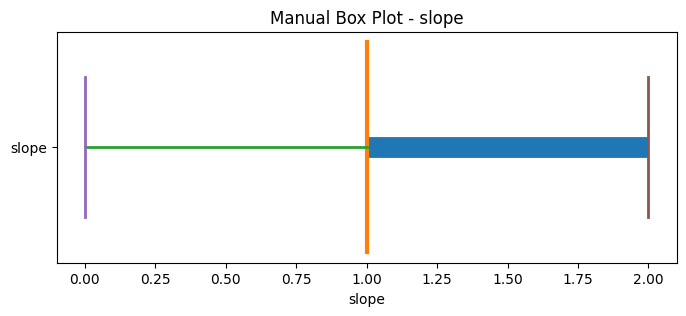

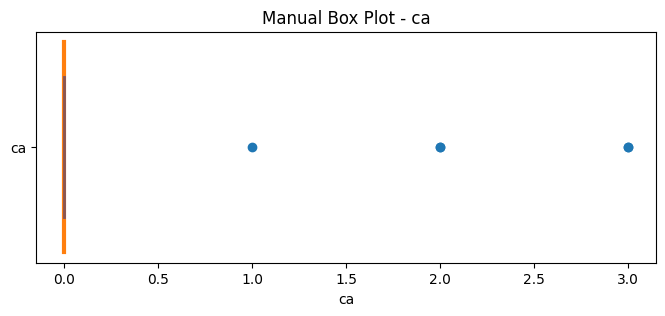

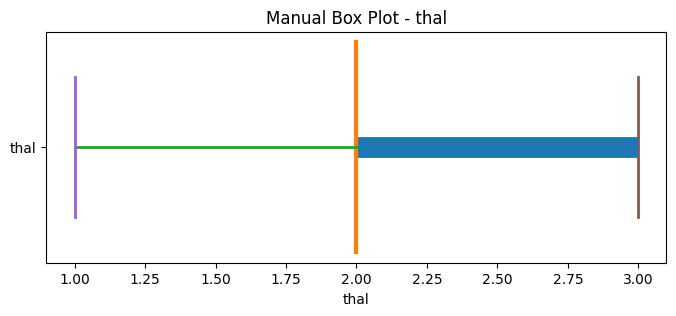

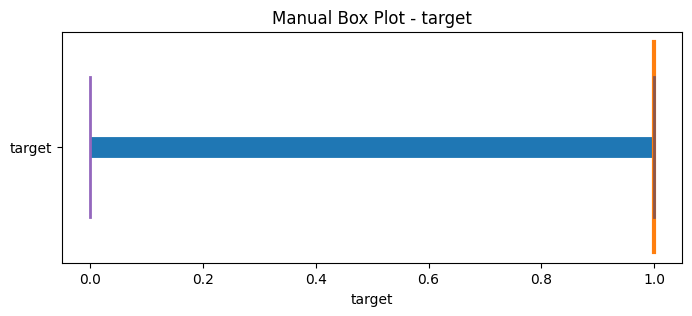

In [10]:
for column in numeric_columns:

    data = processed_df[column].dropna().values
    data = np.sort(data)

    q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    q3 = np.percentile(data, 75)

    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    lower_whisker = data[data >= lower_fence].min()
    upper_whisker = data[data <= upper_fence].max()

    outliers = data[
        (data < lower_fence) |
        (data > upper_fence)
    ]

    plt.figure(figsize=(8, 3))

    plt.plot(
        [q1, q3],
        [1, 1],
        linewidth=15,
        solid_capstyle="butt"
    )

    plt.plot(
        [median, median],
        [0.85, 1.15],
        linewidth=3
    )

    plt.plot(
        [lower_whisker, q1],
        [1, 1],
        linewidth=2
    )

    plt.plot(
        [q3, upper_whisker],
        [1, 1],
        linewidth=2
    )

    plt.plot(
        [lower_whisker, lower_whisker],
        [0.9, 1.1],
        linewidth=2
    )

    plt.plot(
        [upper_whisker, upper_whisker],
        [0.9, 1.1],
        linewidth=2
    )

    if len(outliers) > 0:
        plt.scatter(
            outliers,
            np.ones(len(outliers)),
            marker="o"
        )

    plt.yticks([1], [column])
    plt.xlabel(column)
    plt.title("Manual Box Plot - " + column)

    plt.show()

### 4)Display bar plots for categorical variables without using high-level plotting libraries, dynamically adjusting bar widths and colors for better interpretation.

In [11]:
categorical = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak", 
    "slope",	
    "ca",
    "thal",	
    "target"
]

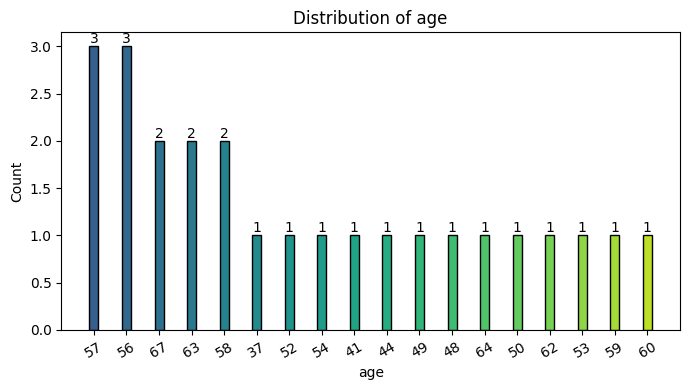

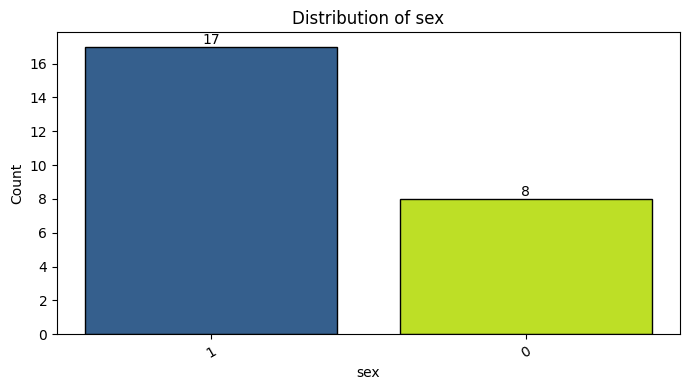

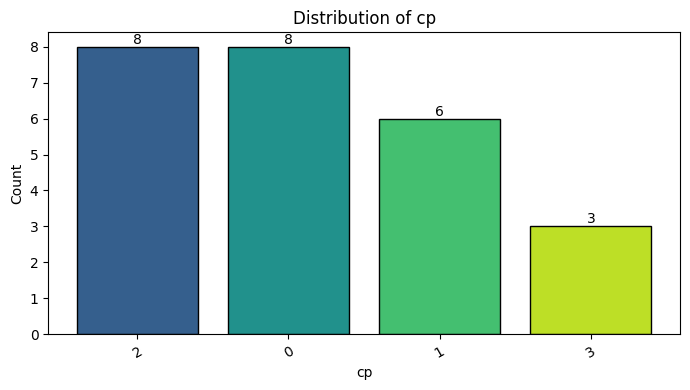

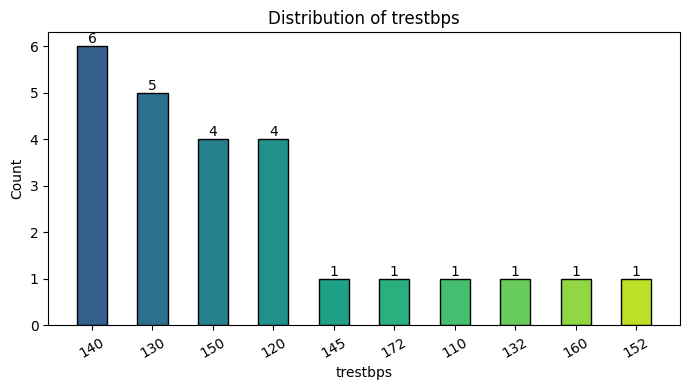

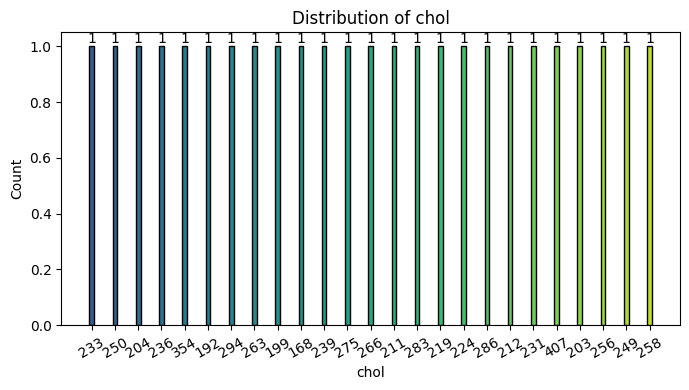

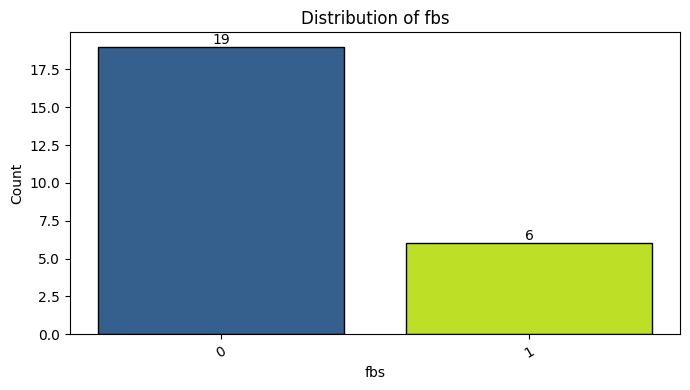

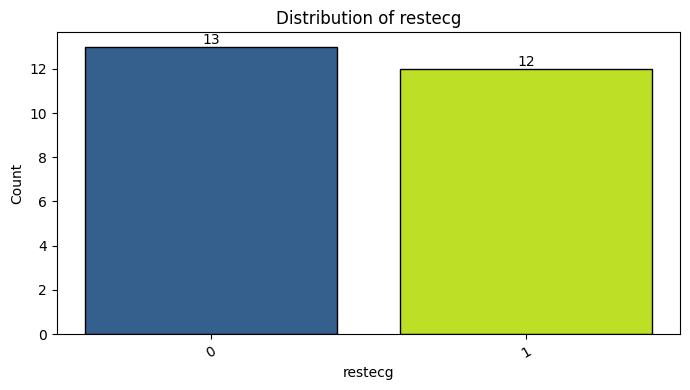

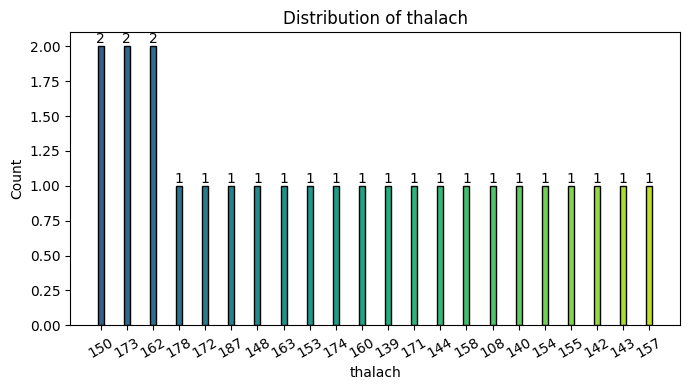

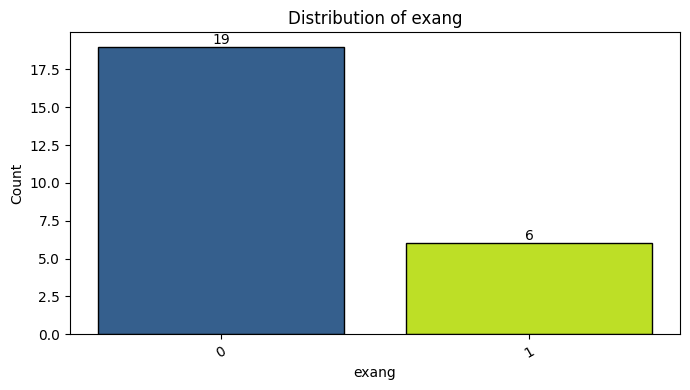

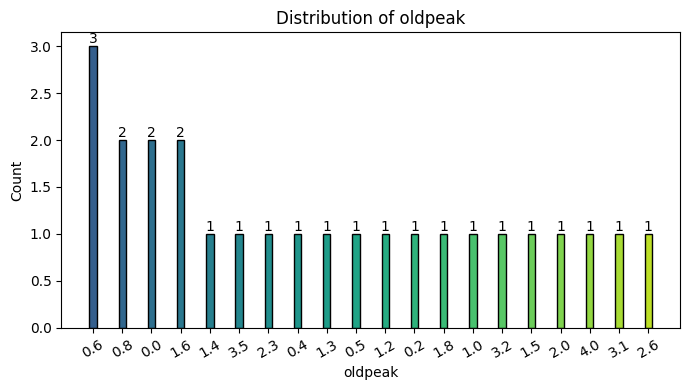

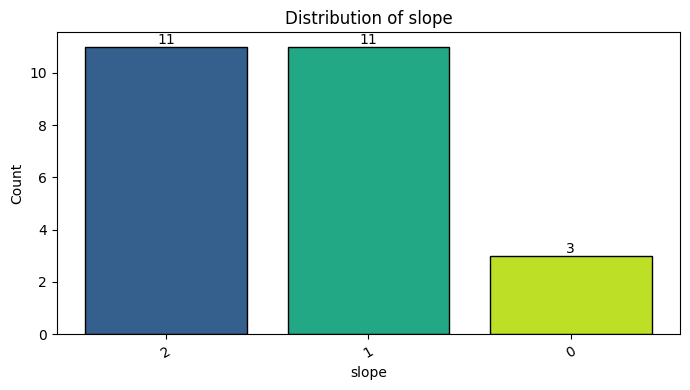

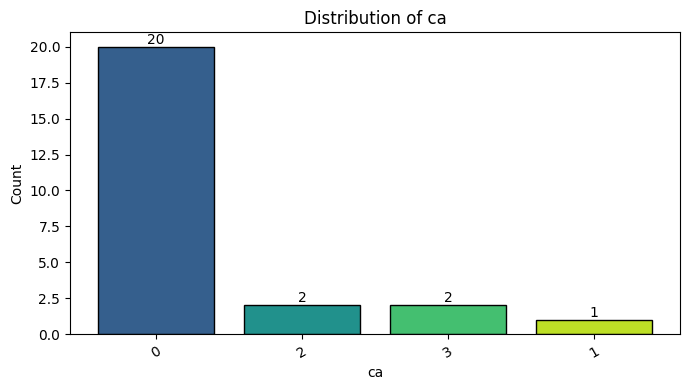

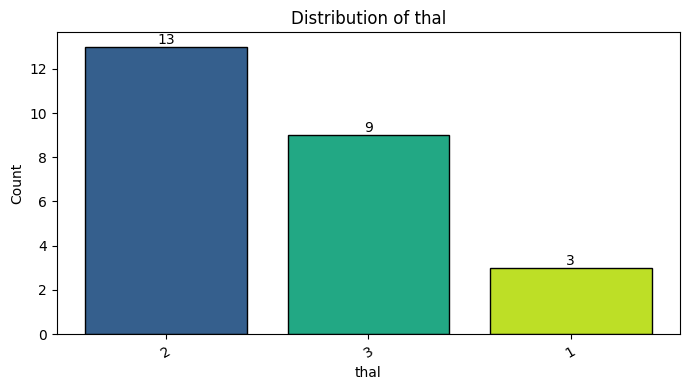

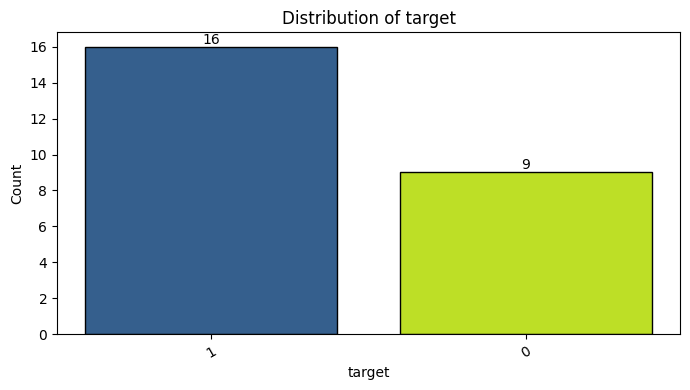

In [12]:

for column in categorical:

    counts = df[column].value_counts()

    x = np.arange(len(counts))

    bar_width = min(0.8, 5 / len(counts))

    colors = plt.cm.viridis(
        np.linspace(0.3, 0.9, len(counts))
    )

    plt.figure(figsize=(7, 4))

    plt.bar(
        x,
        counts.values,
        width=bar_width,
        color=colors,
        edgecolor="black"
    )

    plt.xticks(
        x,
        counts.index,
        rotation=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    for i, value in enumerate(counts.values):
        plt.text(
            i,
            value,
            str(value),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

### 5)Create a heatmap of missing values (if applicable) using a manually constructed grid, mapping missing data points with custom color gradients instead of using Seaborn or Matplotlib heatmap functions.	

In [13]:
missing_data = df.isnull()

missing_count = missing_data.sum().sum()

print("Total missing values:", missing_count)

if missing_count == 0:
    print("No missing values found in the dataset.")
else:

    rows, cols = missing_data.shape

    plt.figure(figsize=(14, 8))

    for i in range(rows):
        for j in range(cols):

            if missing_data.iloc[i, j]:
                color = plt.cm.Reds(0.9)
            else:
                color = plt.cm.Greens(0.15)

            rectangle = plt.Rectangle(
                (j, i),
                1,
                1,
                facecolor=color,
                edgecolor="white",
                linewidth=0.5
            )

            plt.gca().add_patch(rectangle)

    plt.xlim(0, cols)
    plt.ylim(rows, 0)

    plt.xticks(
        np.arange(cols) + 0.5,
        df.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        np.arange(rows) + 0.5,
        np.arange(1, rows + 1)
    )

    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.title("Heatmap of Missing Values")

    plt.tight_layout()
    plt.show()

Total missing values: 0
No missing values found in the dataset.


### Display pair plots for correlated features by manually computing correlation coefficients, selecting highly correlated pairs dynamically, and plotting scatter plots with trendlines using low-level plotting functions.

Correlation Matrix:
               age  trestbps      chol   thalach   oldpeak
age       1.000000  0.362860  0.138549 -0.619402  0.089233
trestbps  0.362860  1.000000 -0.025737 -0.292254  0.111483
chol      0.138549 -0.025737  1.000000 -0.148653  0.147896
thalach  -0.619402 -0.292254 -0.148653  1.000000  0.151625
oldpeak   0.089233  0.111483  0.147896  0.151625  1.000000


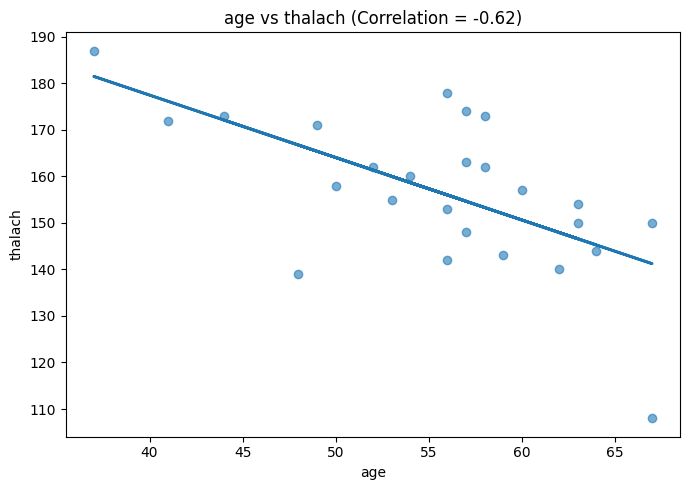

age and thalach have correlation: -0.62


In [14]:
columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]

correlation = df[columns].corr()

print("Correlation Matrix:")
print(correlation)

threshold = 0.5

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        corr = correlation.iloc[i, j]

        if abs(corr) >= threshold:

            x = df[columns[i]]
            y = df[columns[j]]

            slope, intercept = np.polyfit(x, y, 1)

            line = slope * x + intercept

            plt.figure(figsize=(7, 5))

            plt.scatter(
                x,
                y,
                alpha=0.6
            )

            plt.plot(
                x,
                line,
                linewidth=2
            )

            plt.xlabel(columns[i])
            plt.ylabel(columns[j])

            plt.title(
                f"{columns[i]} vs {columns[j]} "
                f"(Correlation = {corr:.2f})"
            )

            plt.tight_layout()
            plt.show()

            print(
                f"{columns[i]} and {columns[j]} "
                f"have correlation: {corr:.2f}"
            )

#### Perform a chi-square test for categorical columns and target by manually computing observed and expected frequencies, applying the chi-square formula step by step, and validating results without using statistical libraries

In [15]:
import math

categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

target = "target"

for column in categorical_columns:

    table = {}

    categories = sorted(df[column].dropna().unique())
    targets = sorted(df[target].dropna().unique())

    for category in categories:
        table[category] = {}

        for target_value in targets:

            count = 0

            for i in range(len(df)):

                if (
                    df[column].iloc[i] == category
                    and df[target].iloc[i] == target_value
                ):
                    count += 1

            table[category][target_value] = count

    observed = np.array([
        [table[c][t] for t in targets]
        for c in categories
    ])

    row_totals = observed.sum(axis=1)
    column_totals = observed.sum(axis=0)
    total = observed.sum()

    expected = np.zeros_like(observed, dtype=float)

    for i in range(len(categories)):
        for j in range(len(targets)):

            expected[i, j] = (
                row_totals[i] * column_totals[j]
            ) / total

    chi_square = 0

    for i in range(len(categories)):
        for j in range(len(targets)):

            if expected[i, j] != 0:

                chi_square += (
                    (observed[i, j] - expected[i, j]) ** 2
                ) / expected[i, j]

    rows = len(categories)
    cols = len(targets)

    degrees_of_freedom = (
        (rows - 1) * (cols - 1)
    )

    print("\n--------------------------------")
    print("Column:", column)
    print("--------------------------------")

    print("\nObserved Frequencies:")
    print(observed)

    print("\nExpected Frequencies:")
    print(np.round(expected, 2))

    print("\nChi-Square Value:", round(chi_square, 4))

    print("Degrees of Freedom:", degrees_of_freedom)


--------------------------------
Column: sex
--------------------------------

Observed Frequencies:
[[ 2  6]
 [ 7 10]]

Expected Frequencies:
[[ 2.88  5.12]
 [ 6.12 10.88]]

Chi-Square Value: 0.6179
Degrees of Freedom: 1

--------------------------------
Column: cp
--------------------------------

Observed Frequencies:
[[5 3]
 [1 5]
 [3 5]
 [0 3]]

Expected Frequencies:
[[2.88 5.12]
 [2.16 3.84]
 [2.88 5.12]
 [1.08 1.92]]

Chi-Square Value: 5.1071
Degrees of Freedom: 3

--------------------------------
Column: fbs
--------------------------------

Observed Frequencies:
[[ 6 13]
 [ 3  3]]

Expected Frequencies:
[[ 6.84 12.16]
 [ 2.16  3.84]]

Chi-Square Value: 0.6716
Degrees of Freedom: 1

--------------------------------
Column: restecg
--------------------------------

Observed Frequencies:
[[ 8  5]
 [ 1 11]]

Expected Frequencies:
[[4.68 8.32]
 [4.32 7.68]]

Chi-Square Value: 7.6667
Degrees of Freedom: 1

--------------------------------
Column: exang
-----------------------------

#### Display a stacked bar chart comparing sex vs target using only raw Matplotlib patches, ensuring proper alignment, color coding, and proportion calculations without using high-level bar chart functions.

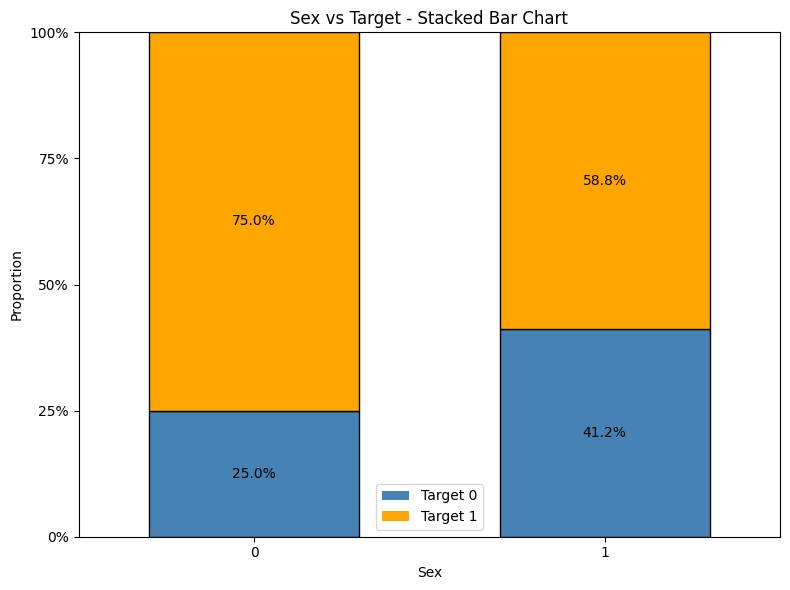

In [16]:
sex_values = sorted(df["sex"].unique())
target_values = sorted(df["target"].unique())

counts = {}

for sex in sex_values:

    counts[sex] = {}

    for target in target_values:

        count = 0

        for i in range(len(df)):

            if (
                df["sex"].iloc[i] == sex
                and df["target"].iloc[i] == target
            ):
                count += 1

        counts[sex][target] = count

plt.figure(figsize=(8, 6))

x_positions = range(len(sex_values))

colors = ["steelblue", "orange"]

for i, sex in enumerate(sex_values):

    total = sum(counts[sex].values())

    bottom = 0

    for j, target in enumerate(target_values):

        count = counts[sex][target]

        proportion = count / total

        rectangle = Rectangle(
            (
                i - 0.3,
                bottom
            ),
            0.6,
            proportion,
            facecolor=colors[j],
            edgecolor="black"
        )

        plt.gca().add_patch(rectangle)

        plt.text(
            i,
            bottom + proportion / 2,
            f"{proportion * 100:.1f}%",
            ha="center",
            va="center"
        )

        bottom += proportion

plt.xlim(-0.5, len(sex_values) - 0.5)
plt.ylim(0, 1)

plt.xticks(
    list(x_positions),
    sex_values
)

plt.yticks(
    [0, 0.25, 0.50, 0.75, 1.0],
    ["0%", "25%", "50%", "75%", "100%"]
)

plt.xlabel("Sex")
plt.ylabel("Proportion")
plt.title("Sex vs Target - Stacked Bar Chart")

plt.legend(
    [
        Rectangle((0, 0), 1, 1, facecolor=colors[0]),
        Rectangle((0, 0), 1, 1, facecolor=colors[1])
    ],
    [
        "Target 0",
        "Target 1"
    ]
)

plt.tight_layout()
plt.show()

#### Identify outliers using IQR and Z-score methods by manually computing quartiles, standard deviations, and thresholds without using built-in statistical functions, and visualize them using a custom plotting approach.


Column: age
Q1: 52
Q3: 60
IQR: 8
IQR Lower Limit: 40.0
IQR Upper Limit: 72.0
IQR Outliers: 1
Mean: 55.52
Standard Deviation: 7.424930976110147
Z-score Outliers: 0


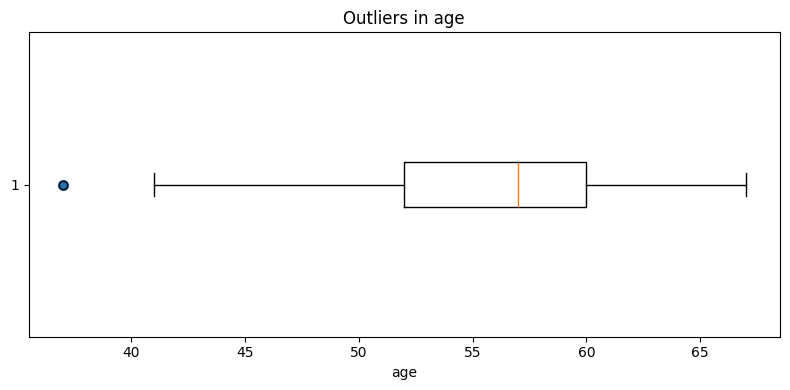


Column: trestbps
Q1: 130
Q3: 150
IQR: 20
IQR Lower Limit: 100.0
IQR Upper Limit: 180.0
IQR Outliers: 0
Mean: 137.64
Standard Deviation: 14.02534848051912
Z-score Outliers: 0


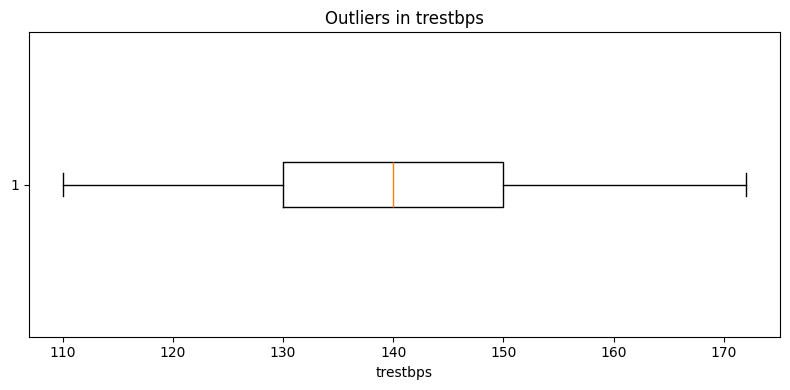


Column: chol
Q1: 212
Q3: 266
IQR: 54
IQR Lower Limit: 131.0
IQR Upper Limit: 347.0
IQR Outliers: 2
Mean: 248.48
Standard Deviation: 50.383425846204624
Z-score Outliers: 1


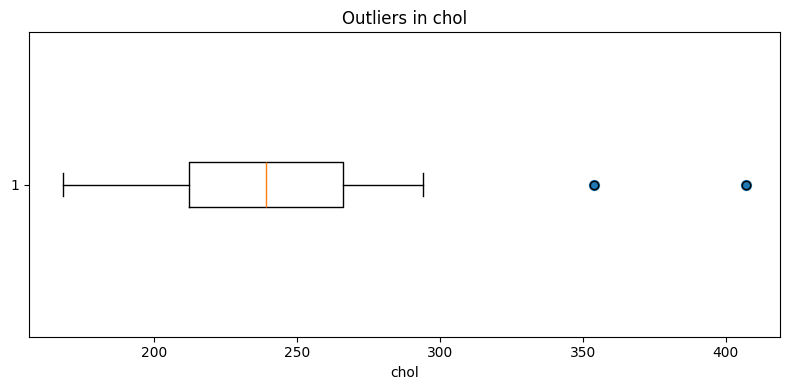


Column: thalach
Q1: 148
Q3: 171
IQR: 23
IQR Lower Limit: 113.5
IQR Upper Limit: 205.5
IQR Outliers: 1
Mean: 156.64
Standard Deviation: 16.084476988699382
Z-score Outliers: 1


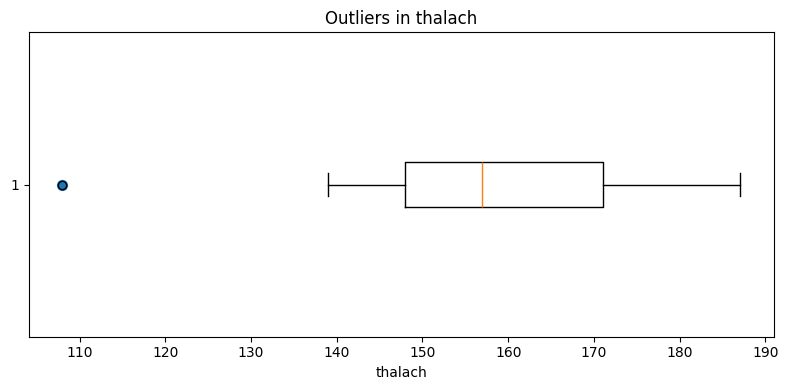


Column: oldpeak
Q1: 0.6
Q3: 2.0
IQR: 1.4
IQR Lower Limit: -1.4999999999999996
IQR Upper Limit: 4.1
IQR Outliers: 0
Mean: 1.464
Standard Deviation: 1.0968609756938206
Z-score Outliers: 0


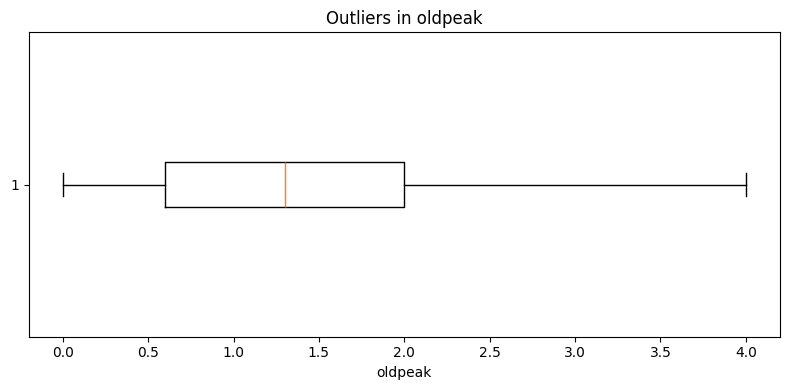

In [17]:
columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for column in columns:

    data = df[column].dropna().values

    data_sorted = np.sort(data)

    n = len(data_sorted)

    q1 = data_sorted[int(0.25 * n)]
    q3 = data_sorted[int(0.75 * n)]

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    iqr_outliers = data[
        (data < lower_bound) |
        (data > upper_bound)
    ]

    mean = sum(data) / len(data)

    variance = sum(
        (x - mean) ** 2 for x in data
    ) / len(data)

    std = variance ** 0.5

    z_scores = (data - mean) / std

    z_outliers = data[
        np.abs(z_scores) > 3
    ]

    print("\nColumn:", column)

    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", iqr)

    print("IQR Lower Limit:", lower_bound)
    print("IQR Upper Limit:", upper_bound)

    print("IQR Outliers:", len(iqr_outliers))

    print("Mean:", mean)
    print("Standard Deviation:", std)

    print("Z-score Outliers:", len(z_outliers))

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        data,
        vert=False
    )

    plt.scatter(
        iqr_outliers,
        np.ones(len(iqr_outliers)),
        marker="o",
        s=50
    )

    plt.title(
        f"Outliers in {column}"
    )

    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

#### Remove or transform extreme outliers by implementing multiple outlier-handling strategies, such as Winsorization and log transformations, and justify the chosen method with a comparative analysis.

In [19]:
winsorized_df = df.copy()

for col in columns:
    values = winsorized_df[col].dropna().values

    sorted_values = np.sort(values)
    n = len(sorted_values)

    q1_index = int(0.25 * (n - 1))
    q3_index = int(0.75 * (n - 1))

    q1 = sorted_values[q1_index]
    q3 = sorted_values[q3_index]

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    winsorized_df[col] = winsorized_df[col].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print(winsorized_df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0    150.0      0      2.3      0   
1   40    1   2       130   250    0        1    187.0      0      3.5      0   
2   41    0   1       130   204    0        0    172.0      0      1.4      2   
3   56    1   1       120   236    0        1    178.0      0      0.8      2   
4   57    0   0       120   347    0        1    163.0      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [20]:
log_df = df.copy()

for col in columns:
    minimum = log_df[col].min()

    if minimum <= 0:
        shifted = log_df[col] - minimum + 1
        log_df[col] = np.log1p(shifted)
    else:
        log_df[col] = np.log1p(log_df[col])

print(log_df.head())

        age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  4.158883    1   3  4.983607  5.455321    1        0  5.017280      0   
1  3.637586    1   2  4.875197  5.525453    0        1  5.236442      0   
2  3.737670    0   1  4.875197  5.323010    0        0  5.153292      0   
3  4.043051    1   1  4.795791  5.468060    0        1  5.187386      0   
4  4.060443    0   0  4.795791  5.872118    0        1  5.099866      1   

    oldpeak  slope  ca  thal  target  
0  1.458615      0   0     1       1  
1  1.704748      0   0     2       1  
2  1.223775      2   0     2       1  
3  1.029619      2   0     2       1  
4  0.955511      2   0     2       1  


In [24]:
comparison = pd.DataFrame(index=columns)

comparison["Original Mean"] = [
    df[col].mean() for col in columns
]

comparison["Winsorized Mean"] = [
    winsorized_df[col].mean() for col in columns
]

comparison["Log Mean"] = [
    log_df[col].mean() for col in columns
]

comparison["Original Std"] = [
    df[col].std() for col in columns
]

comparison["Winsorized Std"] = [
    winsorized_df[col].std() for col in columns
]

comparison["Log Std"] = [
    log_df[col].std() for col in columns
]

print(comparison)

          Original Mean  Winsorized Mean  Log Mean  Original Std  \
age              55.520           55.640  4.025171      7.578038   
trestbps        137.640          137.640  4.926778     14.314561   
chol            248.480          245.800  5.501025     51.422369   
thalach         156.640          156.860  5.054706     16.416151   
oldpeak           1.464            1.464  1.194670      1.119479   

          Winsorized Std   Log Std  
age             7.290862  0.143518  
trestbps       14.314561  0.103141  
chol           43.984846  0.191465  
thalach        15.760922  0.110402  
oldpeak         1.119479  0.312943  


In [26]:
remaining_outliers = {}

for col in columns:
    values = winsorized_df[col].values

    sorted_values = np.sort(values)
    n = len(sorted_values)

    q1_index = int(0.25 * (n - 1))
    q3_index = int(0.75 * (n - 1))

    q1 = sorted_values[q1_index]
    q3 = sorted_values[q3_index]

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    count = np.sum(
        (values < lower_limit) |
        (values > upper_limit)
    )

    remaining_outliers[col] = count

comparison["Remaining Outliers"] = [
    remaining_outliers[col] for col in columns
]

print(comparison)

          Original Mean  Winsorized Mean  Log Mean  Original Std  \
age              55.520           55.640  4.025171      7.578038   
trestbps        137.640          137.640  4.926778     14.314561   
chol            248.480          245.800  5.501025     51.422369   
thalach         156.640          156.860  5.054706     16.416151   
oldpeak           1.464            1.464  1.194670      1.119479   

          Winsorized Std   Log Std  Remaining Outliers  
age             7.290862  0.143518                   0  
trestbps       14.314561  0.103141                   0  
chol           43.984846  0.191465                   0  
thalach        15.760922  0.110402                   0  
oldpeak         1.119479  0.312943                   0  


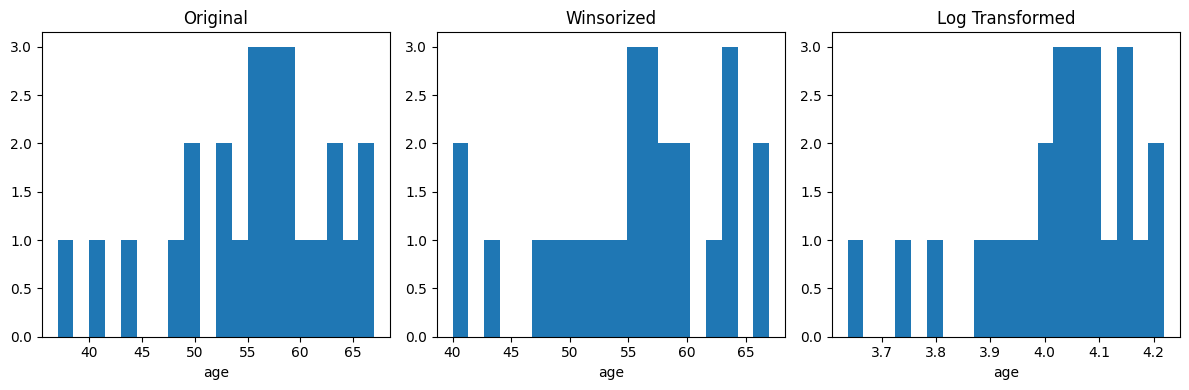

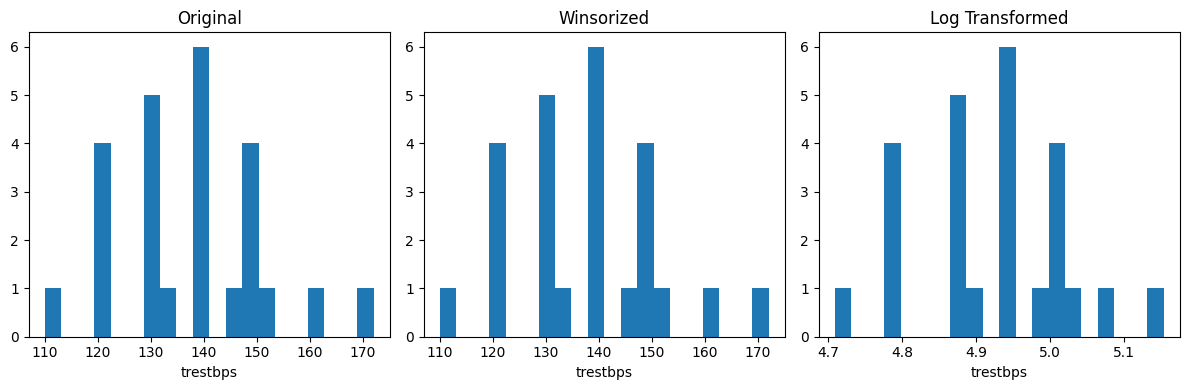

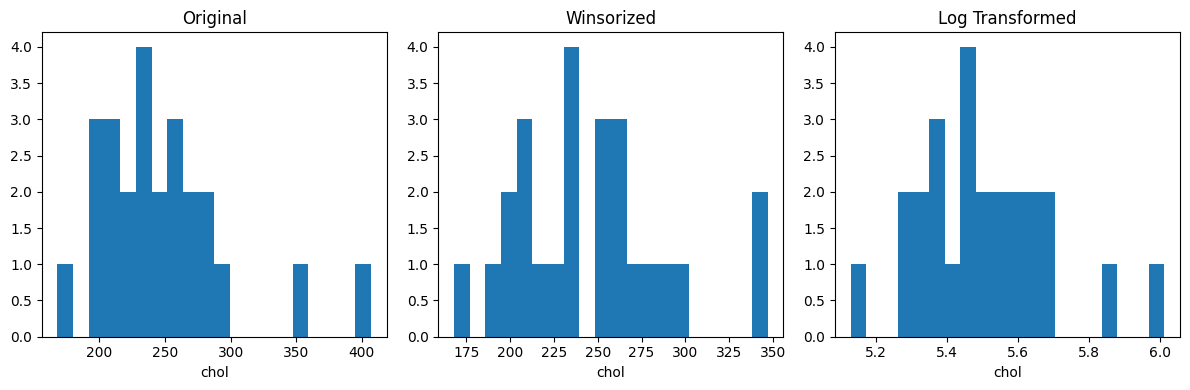

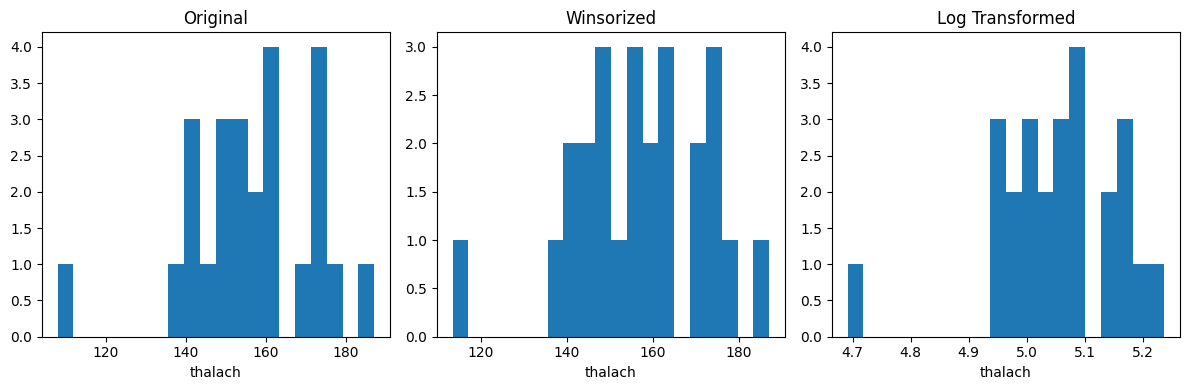

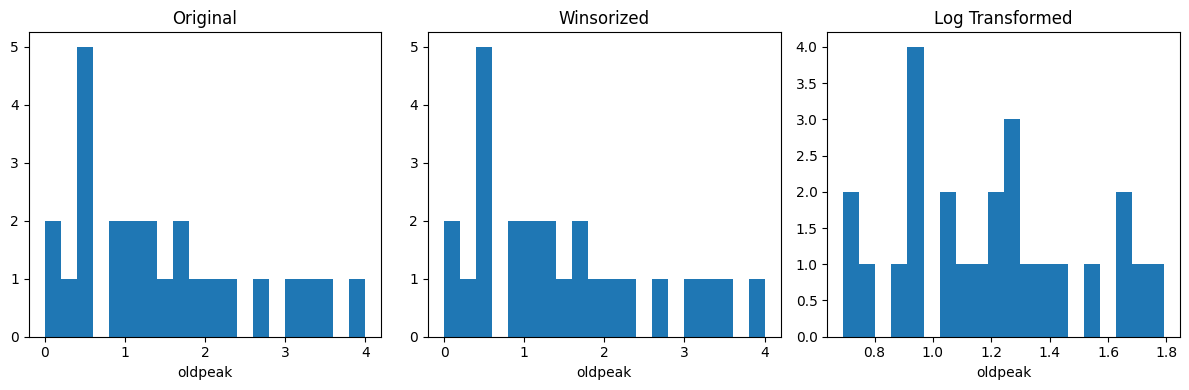

In [27]:
for col in columns:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.hist(df[col], bins=20)
    plt.title("Original")
    plt.xlabel(col)

    plt.subplot(1, 3, 2)
    plt.hist(winsorized_df[col], bins=20)
    plt.title("Winsorized")
    plt.xlabel(col)

    plt.subplot(1, 3, 3)
    plt.hist(log_df[col], bins=20)
    plt.title("Log Transformed")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

#### Use Variance Inflation Factor (VIF) to detect multicollinearity by manually computing R-squared values for each feature without using built-in regression or multicollinearity functions, and provide a detailed interpretation of results.

In [28]:
features = df.drop(columns=["target"])

numeric_features = features.select_dtypes(
    include=[np.number]
).columns.tolist()

print(numeric_features)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [29]:
X = df[numeric_features].copy()

X = X.fillna(X.mean())

X_values = X.values.astype(float)

print("Number of features:", X_values.shape[1])

Number of features: 13


In [30]:
def calculate_r_squared(X, y):
    
    X_with_intercept = np.column_stack(
        (np.ones(X.shape[0]), X)
    )
    
    XT = X_with_intercept.T
    
    XT_X = XT @ X_with_intercept
    XT_y = XT @ y
    
    beta = np.linalg.pinv(XT_X) @ XT_y
    
    y_pred = X_with_intercept @ beta
    
    y_mean = np.mean(y)
    
    ss_total = np.sum((y - y_mean) ** 2)
    ss_residual = np.sum((y - y_pred) ** 2)
    
    r_squared = 1 - (ss_residual / ss_total)
    
    return r_squared

In [31]:
vif_results = []

for i, feature in enumerate(numeric_features):
    
    y = X_values[:, i]
    
    other_indices = [
        j for j in range(len(numeric_features))
        if j != i
    ]
    
    X_other = X_values[:, other_indices]
    
    r_squared = calculate_r_squared(
        X_other,
        y
    )
    
    vif = 1 / (1 - r_squared)
    
    vif_results.append({
        "Feature": feature,
        "R_squared": r_squared,
        "VIF": vif
    })

vif_df = pd.DataFrame(vif_results)

print(vif_df)

     Feature  R_squared       VIF
0        age   0.560665  2.276168
1        sex   0.573658  2.345533
2         cp   0.431338  1.758515
3   trestbps   0.581210  2.387830
4       chol   0.559254  2.268882
5        fbs   0.473516  1.899392
6    restecg   0.592379  2.453260
7    thalach   0.769909  4.346116
8      exang   0.608882  2.556771
9    oldpeak   0.779440  4.533918
10     slope   0.729029  3.690428
11        ca   0.765026  4.255798
12      thal   0.282439  1.393609


In [32]:
vif_df = vif_df.sort_values(
    by="VIF",
    ascending=False
)

print(vif_df.to_string(index=False))

 Feature  R_squared      VIF
 oldpeak   0.779440 4.533918
 thalach   0.769909 4.346116
      ca   0.765026 4.255798
   slope   0.729029 3.690428
   exang   0.608882 2.556771
 restecg   0.592379 2.453260
trestbps   0.581210 2.387830
     sex   0.573658 2.345533
     age   0.560665 2.276168
    chol   0.559254 2.268882
     fbs   0.473516 1.899392
      cp   0.431338 1.758515
    thal   0.282439 1.393609


In [33]:
def interpret_vif(vif):
    
    if vif == 1:
        return "No multicollinearity"
    
    elif vif < 5:
        return "Low multicollinearity"
    
    elif vif <= 10:
        return "High multicollinearity"
    
    else:
        return "Severe multicollinearity"


vif_df["Interpretation"] = vif_df["VIF"].apply(
    interpret_vif
)

print(vif_df.to_string(index=False))

 Feature  R_squared      VIF        Interpretation
 oldpeak   0.779440 4.533918 Low multicollinearity
 thalach   0.769909 4.346116 Low multicollinearity
      ca   0.765026 4.255798 Low multicollinearity
   slope   0.729029 3.690428 Low multicollinearity
   exang   0.608882 2.556771 Low multicollinearity
 restecg   0.592379 2.453260 Low multicollinearity
trestbps   0.581210 2.387830 Low multicollinearity
     sex   0.573658 2.345533 Low multicollinearity
     age   0.560665 2.276168 Low multicollinearity
    chol   0.559254 2.268882 Low multicollinearity
     fbs   0.473516 1.899392 Low multicollinearity
      cp   0.431338 1.758515 Low multicollinearity
    thal   0.282439 1.393609 Low multicollinearity


In [34]:
problematic_features = vif_df[
    vif_df["VIF"] > 5
]

print("Features with VIF greater than 5:")

if len(problematic_features) == 0:
    print("No significant multicollinearity detected.")
else:
    print(problematic_features.to_string(index=False))

Features with VIF greater than 5:
No significant multicollinearity detected.
